### Homework 4
Damion Huppert


In [1]:
using Pkg
Pkg.add("JuMP")
using JuMP
Pkg.add("HiGHS")
using HiGHS
Pkg.add("Plots")
using Plots

    Updating registry at `~/.julia/registries/General.toml`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.11/Project.toml`
  No Changes to `~/.julia/environments/v1.11/Manifest.toml`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.11/Project.toml`
  No Changes to `~/.julia/environments/v1.11/Manifest.toml`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.11/Project.toml`
  No Changes to `~/.julia/environments/v1.11/Manifest.toml`


##### Question 1-1

Decision Variables
$$
x_{it} =
\begin{cases}
1, & \text{if I buy from roaster } i \text{ in week } t \\
0, & \text{otherwise}
\end{cases}
$$

Subject to:  
$$
\sum_{i=1}^6 x_{ij} = 1 \quad \forall t \in \{0, 1, 2, 3, 4, 5\}
$$
$$
\sum_{i=0}^5 x_{ij} = 1 \quad \forall i \in \{1, 2, 3, 4, 5, 6\}

$$

Paremeters:  
$$
E_i = b_i (a_i + t)^2 - c_i (a_i + t)
$$

Objective: 
$$
\max{\sum_{i=0}^5\sum_{i=1}^6 E_{it} \cdot x_{it}} \quad \text{ Maximize the enjoyment }
$$

##### Question 1-2

In [2]:
# Given values for each roaster
roasters = 1:6
weeks = 0:5
a = [20, 5, 4, 20, 10, 15]
b = [2, 3, 5, 3, 1, 4]
c = [10, 15, 20, 5, 25, 15]
E = Dict((i, t) => b[i] * (a[i] + t)^2 - c[i] * (a[i] + t) for i in roasters, t in weeks)

model = Model(HiGHS.Optimizer)  

# Decision Variables
@variable(model, x[roasters, weeks], Bin)

# Constraints
# only one roaster per week
@constraint(model, [t in weeks], sum(x[i, t] for i in roasters) == 1)

# only one week per roaster
@constraint(model, [i in roasters], sum(x[i, t] for t in weeks) == 1)

# Objective 
@objective(model, Max, sum(E[i, t] * x[i, t] for i in roasters, t in weeks))

# Solve
set_silent(model)
optimize!(model)

# Display the optimal assignment
println("Optimal Roaster Assignments:")
for i in roasters
    for t in weeks
        if value(x[i, t]) > 0.5
            println("Roaster $i -> Week $t")
        end
    end
end

# Display the maximum enjoyment
println("Maximum Enjoyment: ", objective_value(model))

Optimal Roaster Assignments:
Roaster 1 -> Week 3
Roaster 2 -> Week 1
Roaster 3 -> Week 2
Roaster 4 -> Week 5
Roaster 5 -> Week 0
Roaster 6 -> Week 4
Maximum Enjoyment: 3665.0


##### Question 2-1

Original program:

$$
\max{ 3x_1 + x_2}
$$
$$
4x_1 + x_2 \leq 7 
$$
$$
5x_1 + 2x_2 \leq 10
$$
$$
x_1 , x_2 \geq 0
$$

Dual:  
$$
\min{7\lambda_1 + 10\lambda_2}
$$
$$
4\lambda_1 + 5\lambda_2 \geq 3
$$
$$
\lambda_1 + 2\lambda_2 \geq 1
$$
$$
\lambda_1 , \lambda_2 \geq 0
$$

##### Question 2-2

Check feasiblility:  
Plug into primal:  

$ obj = \frac{17}{3} \quad x_1 = \frac{4}{3} \quad x_2 = \frac{5}{3}  $
$$
4x_1 + x_2 \leq 7 \rightarrow 4\frac{4}{3} + \frac{5}{3} \leq 7 \rightarrow \frac{21}{3} \leq 7 \quad ✅
$$
$$
5x_1 + 2x_2 \leq 10 \rightarrow 5\frac{4}{3} + 2\frac{5}{3} \leq 10 \rightarrow \frac{30}{3} \leq 10 \quad ✅
$$
$$
3x_1 + x_2 \rightarrow 3\frac{4}{3} + \frac{5}{3} = \frac{17}{3} \quad ✅
$$

Plug into Dual:  

All constraints are tight so dual variables are non-zero
$$
4\lambda_1 + 5\lambda_2 = 3
$$
$$
\lambda_1 + 2\lambda_2 = 1
$$
$$
\lambda_1 = \frac{1}{3}
$$
$$
\lambda_2 = \frac{1}{3}
$$
$$
7\lambda_1 + 10\lambda_2 \rightarrow 7\frac{1}{3} + 10\frac{1}{3} \rightarrow \frac{17}{3} \quad ✅
$$

Since primal objective = dual objective = 17/3, by strong duality, the solution is optimal.

##### Question 2-3

When the right-hand side of the second constraint increases from 10 to 12, the objective value in the dual will also increase. 

New dual:
$$
\min{7\lambda_1 + 12\lambda_2}
$$
$$
4\lambda_1 + 5\lambda_2 \geq 3
$$
$$
\lambda_1 + 2\lambda_2 \geq 1
$$
$$
\lambda_1 , \lambda_2 \geq 0
$$

New solution using the same optimal values:
$$
7\lambda_1 + 12\lambda_2 \rightarrow 7\frac{1}{3} + 12\frac{1}{3} \rightarrow \frac{19}{3}
$$

##### Question 2-4

If the right-hand side of the second constraint changes to 15, the optimal solution will likely continue to increase, but the change will be larger.

New dual:
$$
\min{7\lambda_1 + 15\lambda_2}
$$
$$
4\lambda_1 + 5\lambda_2 \geq 3
$$
$$
\lambda_1 + 2\lambda_2 \geq 1
$$
$$
\lambda_1 , \lambda_2 \geq 0
$$

New solution:
$$
7\lambda_1 + 15\lambda_2 \rightarrow 7\frac{1}{3} + 15\frac{1}{3} \rightarrow \frac{22}{3}
$$

##### Question 2-5

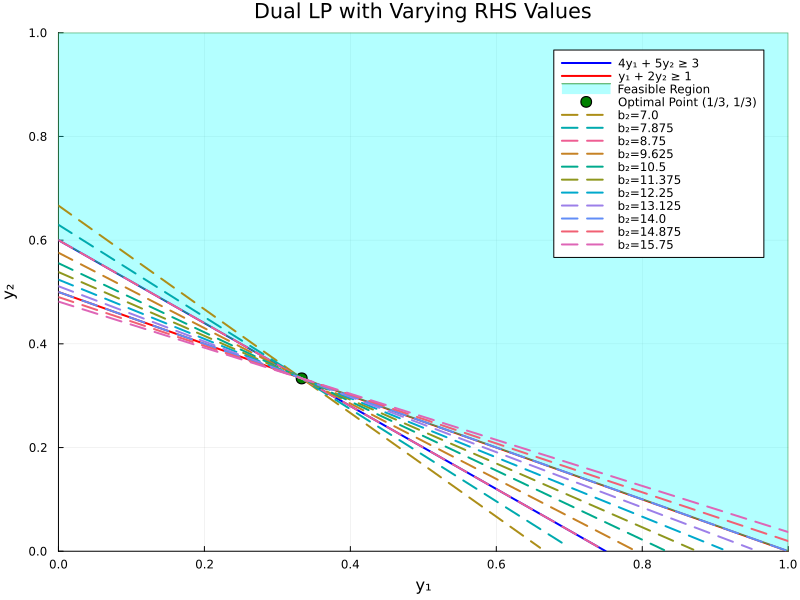

In [13]:
y1_range = 0:0.01:1.5
y2_range = 0:0.01:1

f1(y1) = (3 - 4*y1)/5  # From 4y1 + 5y2 ≥ 3 -> y2 ≥ (3 - 4y1)/5
f2(y1) = (1 - y1)/2    # From y1 + 2y2 ≥ 1 -> y2 ≥ (1 - y1)/2

plot(xlabel="y₁", ylabel="y₂", title="Dual LP with Varying RHS Values", legend=:topright, size=(800, 600), legendfontsize=8)

plot!(y1_range, f1.(y1_range), label="4y₁ + 5y₂ ≥ 3", lw=2, color=:blue)
plot!(y1_range, f2.(y1_range), label="y₁ + 2y₂ ≥ 1", lw=2, color=:red)

y1_points = [0.0, 1/3, 1, 1, 0, 0.0]
y2_points = [0.6, 1/3, 0, 1, 1, 0.6]

plot!(y1_points, y2_points, fill=(0, :cyan, 0.3), lw=1, label="Feasible Region")

scatter!([1/3], [1/3], label="Optimal Point (1/3, 1/3)", color=:green, markersize=6)

function objective_line(y1, b2)
    constant = (7 + b2) / 3
    return (constant - 7*y1) / b2
end

b2_values = 7:1.75/2:16

for (i, b2) in enumerate(b2_values)
    label = (b2 == 10) ? "Original (b₂=10)" : "b₂=$b2"
    linestyle = (b2 == 10) ? :solid : :dash
    y2_func(y1) = objective_line(y1, b2)
    y2_vals = y2_func.(y1_range)
    valid_indices = findall(0 .<= y2_vals .<= 1)
    
    plot!(y1_range[valid_indices], y2_vals[valid_indices], 
          label=label, linestyle=linestyle, lw=2)
end


# # Set limits
xlims!(0, 1)
ylims!(0, 1)

Range: 8.75-14.875

##### Question 2-6

In [ ]:
model = Model(HiGHS.Optimizer)

# Define variables
@variable(model, x1 >= 0)
@variable(model, x2 >= 0)

# Define constraints
@constraint(model, 4x1 + x2 <= 7)
@constraint(model, 5x1 + 2x2 <= 12) # CONSTRAINT TO 12

# Define objective function
@objective(model, Max, 3x1 + x2)

# Optimize  
set_silent(model)
optimize!(model)

# Display results
println("Original Objective value: ", 17/3)
println("Predicted Objective value: ", 19/3)
println("Objective value: ", objective_value(model))
println("x1: ", value(x1))
println("x2: ", value(x2))  


Original Objective value: 5.666666666666667
Predicted Objective value: 6.333333333333333
Objective value: 6.333333333333333
x1: 0.6666666666666664
x2: 4.333333333333334


##### Question 2-7

In [ ]:
model = Model(HiGHS.Optimizer)

# Define variables
@variable(model, x1 >= 0)
@variable(model, x2 >= 0)

# Define constraints
@constraint(model, 4x1 + x2 <= 7)
@constraint(model, 5x1 + 2x2 <= 15) # CONSTRAINT TO 15

# Define objective function
@objective(model, Max, 3x1 + x2)

# Optimize  
set_silent(model)
optimize!(model)

# Display results
println("Original Objective value: ", 17/3)
println("Predicted Objective value: ", 22/3)
println("Objective value: ", objective_value(model))
println("x1: ", value(x1))
println("x2: ", value(x2))  


Original Objective value: 5.666666666666667
Predicted Objective value: 7.333333333333333
Objective value: 7.000000000000001
x1: 0.0
x2: 7.000000000000001


##### Question 3-1

Decision Variables:
$$
R: \text{ Set of restaurants }
$$
$$
d_{ij}: \text{ Distance from restaurant i to restaurant j}
$$
$$
P: \text{ Path taken (start, end) }
$$
$$
x_{ij} \text{ 1 if the path from i to j is taken otherwise 0}
$$

Constraints:  
$$
\sum_{j} x_{\text{ss},j} = 1
$$
$$
\sum_{i} x_{i, \text{a}} = 1
$$
$$
\sum_{i} x_{ik} = \sum_{j} x_{kj} \quad \forall k \neq \text{Short Stack}, \text{Alchemy}
$$

Objective:  
$$
\min{\sum_{(i,j) \in P}d_{ij} \cdot x_{ij}}
$$

DUAL:  

objective:  

only constraints are starting and ending at the right nodes 
$$
\max{ \lambda_{ss} + \lambda_a}
$$

constraints:  

constraint for each decision variable
$$
\lambda_i - \lambda_j \leq d_{ij}, \quad \forall (i,j) \in P
$$

##### Question 3-2

In [ ]:
# Define restaurants
restaurants_end = [:gd, :of, :rs, :iag, :wt, :a]
restaurants_start = [:ss, :gd, :of, :rs, :iag, :wt]
all_restaurants = [:ss, :gd, :of, :rs, :iag, :wt, :a]

# Distance matrix (NamedArray)
dist = NamedArray(
    [4      6      5      100000  100000  100000; 
     100000 1      100000 7       100000  100000; 
     100000 100000 2      5.5     4       100000; 
     100000 100000 100000 100000  5       100000; 
     100000 100000 100000 100000  1       6; 
     100000 100000 100000 100000  100000  8],
    (restaurants_start, restaurants_end),
    ("restaurant", "restaurant")
)

# Create the model
model = Model(HiGHS.Optimizer)

# Decision variables: lambda[i] for each restaurant
@variable(model, lambda[i in all_restaurants])

# Constraints: λ_i - λ_j ≤ d_ij
for i in restaurants_start
    for j in restaurants_end
        if dist[i, j] < 100000  # Only consider valid paths
            @constraint(model, lambda[i] - lambda[j] ≤ dist[i, j])
        end
    end
end

# Objective: Maximize λ_ss + λ_a
@objective(model, Max, lambda[:ss] + lambda[:a])

# Solve the model
optimize!(model)

# Print results
println("Optimal value: ", objective_value(model))
for r in all_restaurants
    println("lambda[$r] = ", value(lambda[r]))
end


Running HiGHS 1.9.0 (git hash: 66f735e60): Copyright (c) 2024 HiGHS under MIT licence terms
Coefficient ranges:
  Matrix [1e+00, 1e+00]
  Cost   [1e+00, 1e+00]
  Bound  [0e+00, 0e+00]
  RHS    [1e+00, 8e+00]
Presolving model
Problem status detected on presolve: Primal infeasible or unbounded
Solving the original LP with primal simplex to determine infeasible or unbounded
Using EKK primal simplex solver
  Iteration        Objective     Infeasibilities num(sum)
          0     0.0000000000e+00 Pr: 0(0); Du: 2(2) 0s
          1     4.0000000000e+00 Pr: 0(0); Du: 2(2) 0s
Model status        : Unbounded
Simplex   iterations: 1
Objective value     :  4.0000000000e+00
Relative P-D gap    :  5.0000000000e-01
HiGHS run time      :          0.00
Solving linear system to compute primal ray
Optimal value: 1.0
lambda[ss] = 0.0
lambda[gd] = 0.0
lambda[of] = 0.0
lambda[rs] = 0.0
lambda[iag] = 0.0
lambda[wt] = 0.0
lambda[a] = 1.0


##### Question 3-3

Because Alchemy is the only none zero dual value we can say it is the bottle neck of the path. If we changed how we can get to Alchemy or changed to a different node our solution could improve

##### Question 4-1

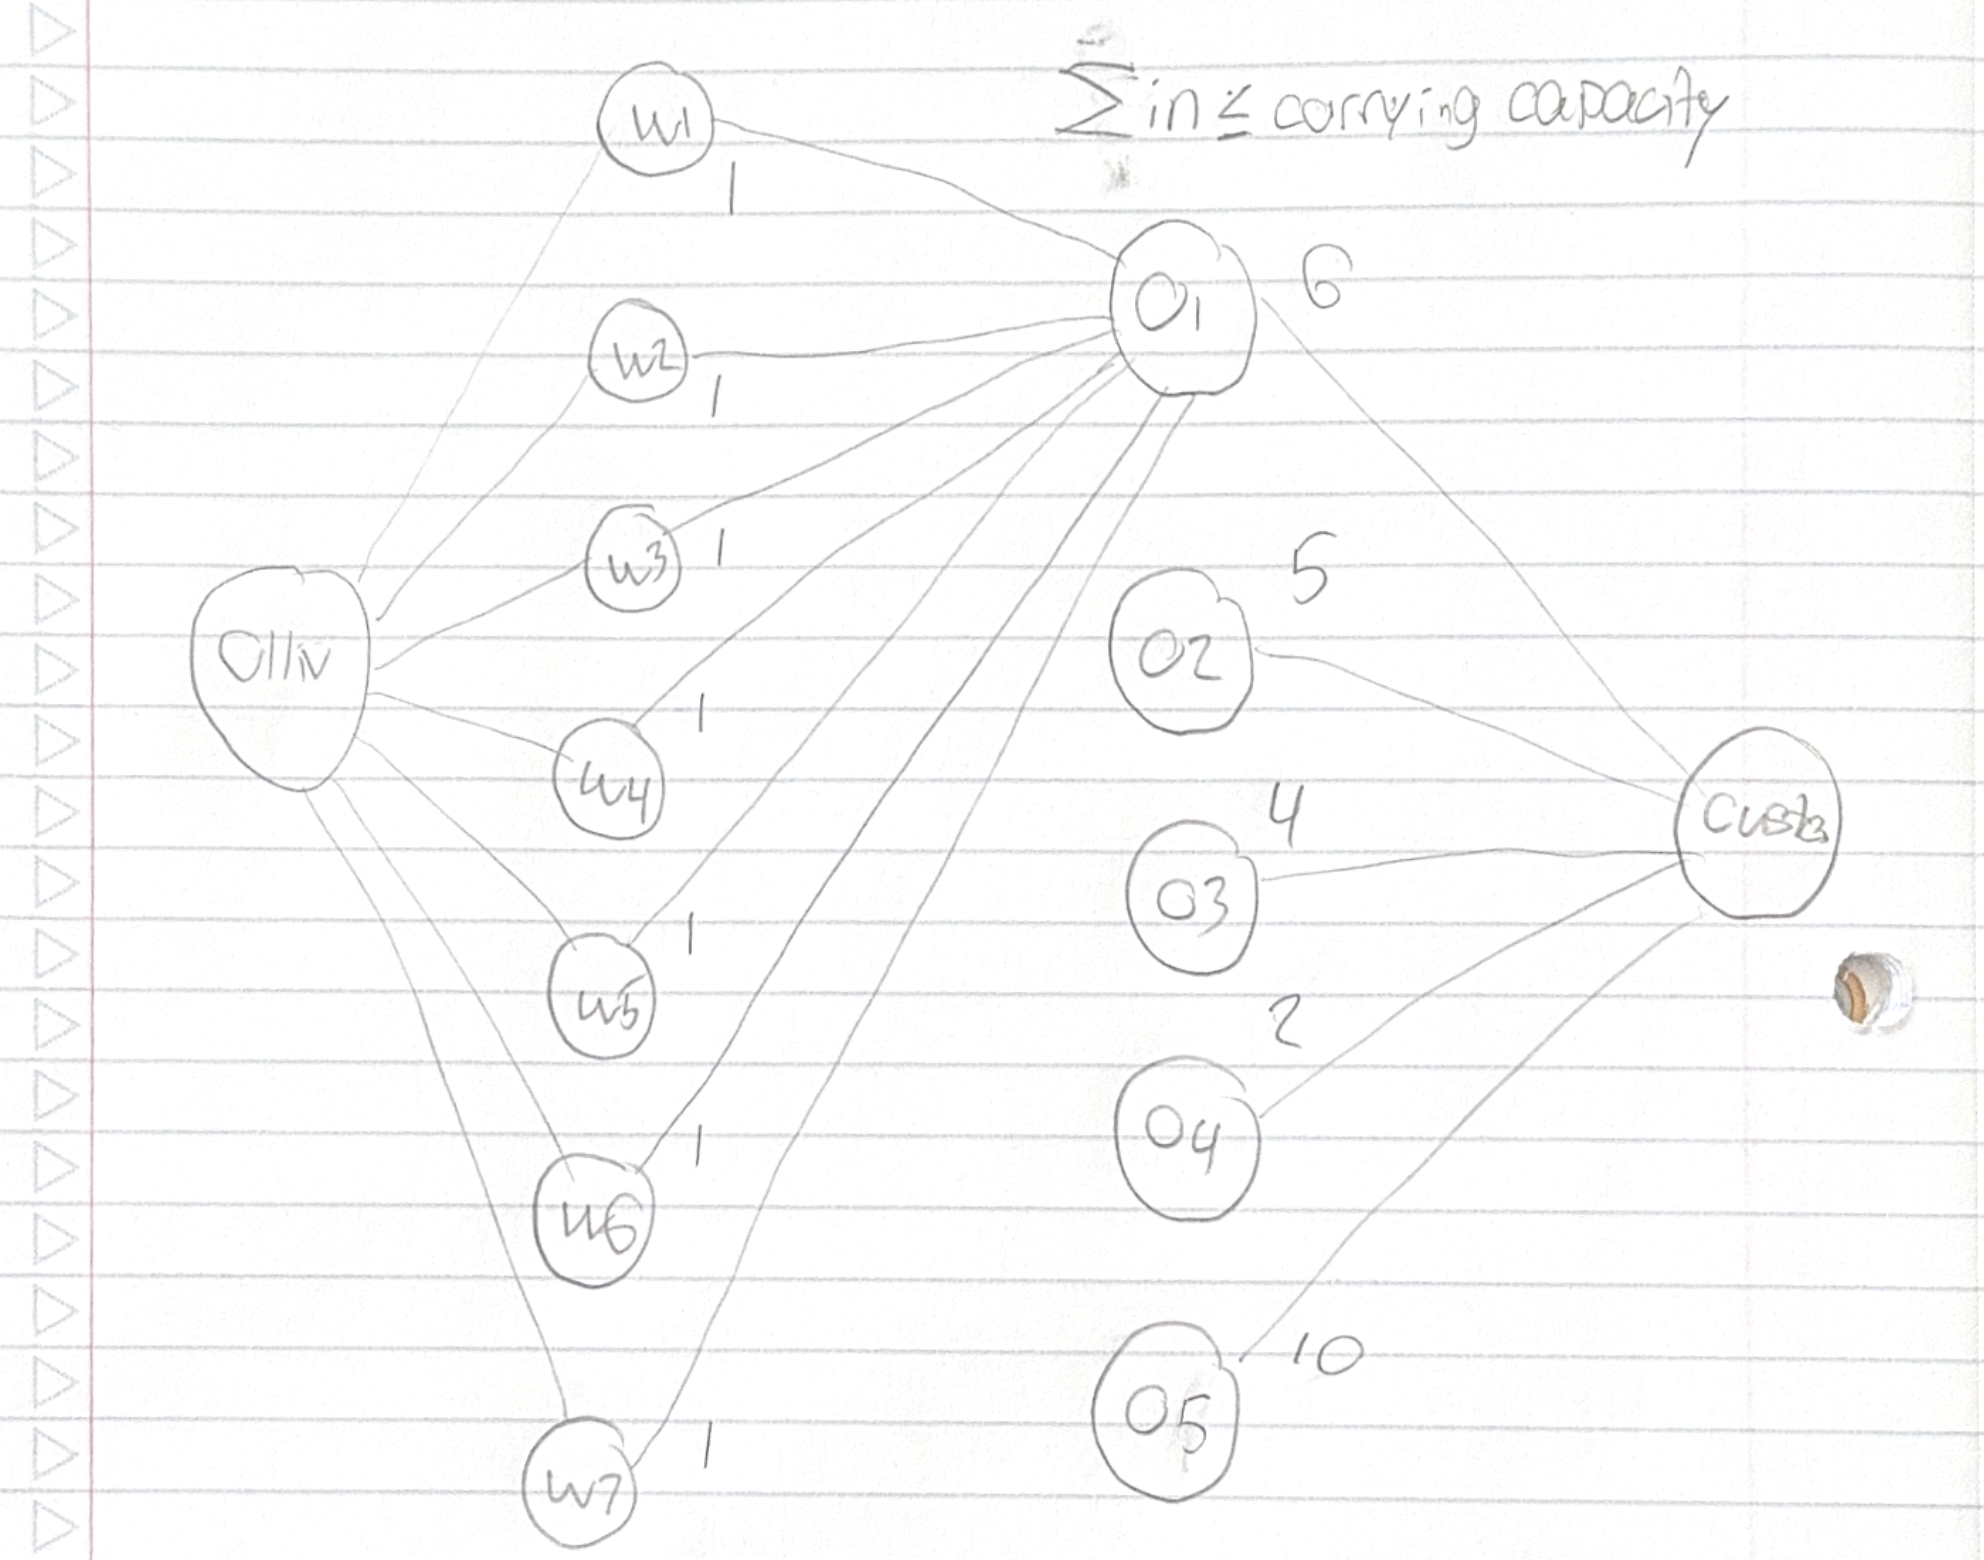

Variables:
$$
w_{ij} =
\begin{cases}
1, & \text{ if wand } i \text{ is carried by owl } j \\
0, & \text{otherwise}
\end{cases}
$$
These below are unneeded but there in spirit:  
$$
source_i \quad \text{ amount of wand type j made by the wizard}
$$
$$
sink_j \quad \text{ amount of wands carried by owl j to the source}
$$

constraint:
$$
\sum_{i=1}^7 w_{ij} \leq CC_j \quad \forall j
$$

objective:
$$
\max{ \sum_{i=1}^7 \sum_{j=1}^5 w_{ij}}
$$

In [15]:
owls_carrying_capaticty  = Dict(1 => 6, 2 => 5, 3 => 4, 4 => 2, 5 => 10)
wands = 1:7
owls = 1:5

model = Model(HiGHS.Optimizer)

# Define variables
@variable(model, w[wands, owls], Bin)

# Define constraints
for owl in owls
  @constraint(model, sum(w[wand, owl] for wand in wands) <= owls_carrying_capaticty[owl])
end

# Define objective function
@objective(model, Max, sum(w[wand, owl] for wand in wands, owl in owls))

# Solve the problem
set_silent(model)
optimize!(model)

# Output results:
println("Maximum number of wands delivered: ", objective_value(model))

# Output the number of wands each owl is carrying:
for owl in owls
    println("Owl ", owl, " carries ", sum(value(w[wand, owl]) for wand in wands), " wands.")
end

# Output the number of wands of each type delivered:
for wand in wands
    println("Wand type ", wand, " is delivered by ", sum(value(w[wand, owl]) for owl in owls), " owls.")
end

# Find the minimum cut (edges that, if removed, would reduce the max flow)
cut_edges = []
for wand in wands
    for owl in owls
        if value(w[wand, owl]) == 0  # Edge is not used, so it could be a cut
            push!(cut_edges, (wand, owl))
        end
    end
end

println("Minimum cut edges: ", cut_edges)

Maximum number of wands delivered: 24.0
Owl 1 carries 6.0 wands.
Owl 2 carries 5.0 wands.
Owl 3 carries 4.0 wands.
Owl 4 carries 2.0 wands.
Owl 5 carries 7.0 wands.
Wand type 1 is delivered by 1.0 owls.
Wand type 2 is delivered by 2.0 owls.
Wand type 3 is delivered by 3.0 owls.
Wand type 4 is delivered by 4.0 owls.
Wand type 5 is delivered by 4.0 owls.
Wand type 6 is delivered by 5.0 owls.
Wand type 7 is delivered by 5.0 owls.
Minimum cut edges: Any[(1, 1), (1, 2), (1, 3), (1, 4), (2, 2), (2, 3), (2, 4), (3, 3), (3, 4), (4, 4), (5, 4)]


##### Question 4-2

In [16]:

function find_min_cut()
    n = 14
    residual = zeros(n, n)
    for i in 2:8  
        residual[1, i] = 100 
    end
    
    for i in 2:8 
        for j in 9:13
            wand = i - 1
            owl = j - 8
            if value(w[wand, owl]) > 0.5
                residual[i, j] = 0
                residual[j, i] = 1
            else
                residual[i, j] = 1
                residual[j, i] = 0
            end
        end
    end
    
    for i in 9:13
        owl = i - 8
        owl_capacity = owls_carrying_capaticty[owl]
        owl_flow = sum(value(w[wand, owl]) for wand in wands)
        
        residual[i, 14] = owl_capacity - owl_flow  
        if owl_flow > 0
            residual[14, i] = owl_flow  
        end
    end
    
    visited = falses(n)
    queue = [1]
    visited[1] = true
    
    while !isempty(queue)
        node = popfirst!(queue)
        for next in 1:n
            if residual[node, next] > 0 && !visited[next]
                push!(queue, next)
                visited[next] = true
            end
        end
    end
    
    source_side = findall(visited)
    sink_side = findall(.!visited)
    
    cut_capacity = 0
    for i in source_side
        for j in sink_side
            if i == 1 && 2 <= j <= 8 
                cut_capacity += 100
            elseif 2 <= i <= 8 && 9 <= j <= 13
                cut_capacity += 1
            elseif 9 <= i <= 13 && j == 14
                owl = i - 8
                cut_capacity += owls_carrying_capaticty[owl]
            end
        end
    end
    
    return source_side, sink_side, cut_capacity
end

source_side, sink_side, cut_capacity = find_min_cut()

function node_name(idx)
    if idx == 1
        return "Source"
    elseif 2 <= idx <= 8
        return "Wand type $(idx-1)"
    elseif 9 <= idx <= 13
        return "Owl $(idx-8)"
    else
        return "Sink"
    end
end

println("\n---- Minimum Cut Solution ----")
println("Source side:")
for node in source_side
    println("  - ", node_name(node))
end

println("\nSink side:")
for node in sink_side
    println("  - ", node_name(node))
end

println("\nMinimum cut capacity: ", cut_capacity)
println("Maximum flow: ", objective_value(model))

println("\nMax flow equals min cut? ", isapprox(objective_value(model), cut_capacity))


---- Minimum Cut Solution ----
Source side:
  - Source
  - Wand type 1
  - Wand type 2
  - Wand type 3
  - Wand type 4
  - Wand type 5
  - Wand type 6
  - Wand type 7
  - Owl 1
  - Owl 2
  - Owl 3
  - Owl 4

Sink side:
  - Owl 5
  - Sink

Minimum cut capacity: 24
Maximum flow: 24.0

Max flow equals min cut? true


##### Question 5-1

Complentary solution:  
$$
x_1 = \frac{28}{5} \quad x_2 = 0 \quad x_3 = \frac{3}{5}
$$
$$
x1 + x2 − x3 \rightarrow \frac{28}{5} + 0 - \frac{3}{5} \rightarrow 5 \geq 5 \quad \text{TIGHT}
$$
$$
x1 − 2x2 + 4x3 \rightarrow \frac{28}{5} - 2*0 + 4\frac{3}{5} \rightarrow 8 \geq 8 \quad \text{TIGHT}
$$

$$
x_1: \quad a_{11}​\lambda_1​+a_{21}​\lambda_2​=c_1​ \implies 1 \cdot \lambda_1 ​+ 1 \cdot \lambda_2 ​= 2
$$
$$
x_3: \quad a_{13}​\lambda_1​+a_{23}​\lambda_2​=c_3 \implies -1 \cdot \lambda_1​ + 4 \cdot \lambda_2 ​= 1
$$

$$
\begin{cases}
y_1 ​+ y_2 ​= 2 \\
-1y_1​ + 4y_2 ​= 1
\end{cases}
$$

$$
\hat{\lambda} = \left(\frac{7}{5}, \frac{3}{5}\right)
$$


##### Question 5-2

Dual:
$$
\max{5\lambda_1 + 8\lambda_2}
$$
subect to:
$$
\lambda_1 + \lambda_2 \leq 2
$$
$$
\lambda_1 - 2\lambda_2 \leq 0
$$
$$
-\lambda_1 + 4\lambda_2 \leq 1
$$

Plug in $\hat{\lambda}$
$$
\lambda_1 - 2\lambda_2 \rightarrow  \frac{7}{5} - 2 \frac{3}{5} \neq 0
$$

This dual solution is not feasible so we can conclude that $\hat{x}$ is not optimal

##### Question 5-3

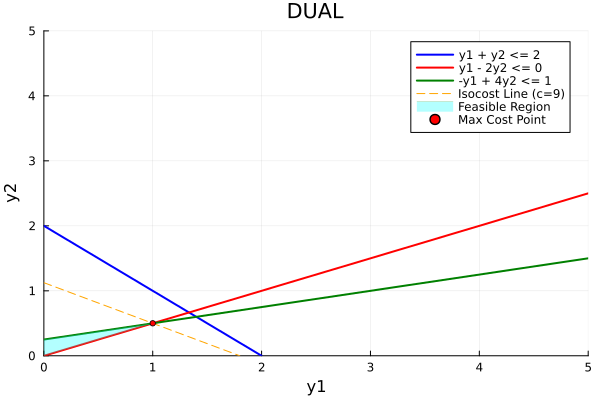

In [ ]:
y1_range = 0:0.1:10
f1(y1) = 2 - y1 
f2(y1) = 1/2*y1
f3(y1) = 1/4 + 1/4*y1

plot(y1_range, f1.(y1_range), label="y1 + y2 <= 2", lw=2, color=:blue)
plot!(y1_range, f2.(y1_range), label="y1 - 2y2 <= 0", lw=2, color=:red)
plot!(y1_range, f3.(y1_range), label="-y1 + 4y2 <= 1", lw=2, color=:green)

# isocost lines
isocost_line(y1) = c/8 - 5/8*y1
c = 9
plot!(y1_range, isocost_line.(y1_range), label="Isocost Line (c=9)", linestyle=:dash, lw=1, color=:orange)

# feasiable region
y1_vals = [0, 0, 1, 0]
y2_vals = [0, 1/4, 1/2, 0]
plot!(y1_vals, y2_vals, fill=(0, :cyan, 0.3), lw=0, label="Feasible Region")

max_cost_point = [1, 1/2]
scatter!([max_cost_point[1]], [max_cost_point[2]], label="Max Cost Point", color=:red, markersize=3)
      
xlabel!("y1")
ylabel!("y2")

title!("DUAL")

xlims!(0, 5)
ylims!(0, 5)


The optimal point is at $ \hat{\lambda} = \left(1, \frac{1}{2} \right) $

##### Question 5-4

$$
​x_1 ​+ ​x_2 - ​x_3 = 5
$$
$$
​x_1 ​+ 2​x_2 + ​4x_3 = 8 
$$
$$
\hat{x} = \left(0, 14.0, 9.0 \right)
$$

##### Question 5-5

DUAL:

objective: 
$$
\max{8\lambda_1 + 17\lambda_2 + 9\lambda_3}
$$
subject to:
$$
2\lambda_2 + \lambda_3 \leq 4
$$
$$
-\lambda_1 \leq -1
$$
$$
\lambda_1 = 0
$$
$$
\lambda_2 = 6
$$